In [ ]:
!pip install xgboost

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from xgboost import XGBRegressor

import matplotlib.pyplot as plt

In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv"

df = pd.read_csv(url)

df.head()

,Month,Sales
0,1960-01,6550
1,1960-02,8728
2,1960-03,12026
3,1960-04,14395
4,1960-05,14587


In [ ]:
df.columns = ['date','sales']

df['date'] = pd.to_datetime(df['date'])

df.head()

,date,sales
0,1960-01-01,6550
1,1960-02-01,8728
2,1960-03-01,12026
3,1960-04-01,14395
4,1960-05-01,14587


In [ ]:
df['month'] = df['date'].dt.month

df['year'] = df['date'].dt.year

df['quarter'] = df['date'].dt.quarter

In [ ]:
df['lag1'] = df['sales'].shift(1)
df['lag2'] = df['sales'].shift(2)
df['lag3'] = df['sales'].shift(3)
df['lag6'] = df['sales'].shift(6)
df['lag12'] = df['sales'].shift(12)

In [ ]:
df['time_index'] = range(len(df))

In [ ]:
df['rolling_mean_3'] = df['sales'].rolling(3).mean()
df['rolling_mean_6'] = df['sales'].rolling(6).mean()

df['rolling_std_3'] = df['sales'].rolling(3).std()
df['rolling_std_6'] = df['sales'].rolling(6).std()

In [ ]:
df.dropna(inplace=True)

df.head()

,date,sales,month,year,quarter,lag1,lag2,lag3,rolling_mean_3,rolling_mean_6,lag6,lag12,rolling_std_3,rolling_std_6
17,1961-06-01,13821,6,1961,2,15926.0,13784.0,11837.0,14510.333333,11996.500000,8456.0,13791.0,1226.142868,3210.006651
18,1961-07-01,11143,7,1961,3,13821.0,15926.0,13784.0,13630.000000,12647.500000,7237.0,9498.0,2397.213591,2326.092410
19,1961-08-01,7975,8,1961,3,11143.0,13821.0,15926.0,10979.666667,12414.333333,9374.0,8251.0,2926.420567,2751.137341
20,1961-09-01,7610,9,1961,3,7975.0,11143.0,13821.0,8909.333333,11709.833333,11837.0,7049.0,1943.001887,3394.529918
21,1961-10-01,10015,10,1961,4,7610.0,7975.0,11143.0,8533.333333,11081.666667,13784.0,9545.0,1296.074201,3280.759038


In [ ]:
X = df[
    [
        'month',
        'year',
        'quarter',
        'time_index',
        'lag1',
        'lag2',
        'lag3',
        'lag6',
        'lag12',
        'rolling_mean_3',
        'rolling_mean_6',
        'rolling_std_3',
        'rolling_std_6'
    ]
]

y = df['sales']

In [ ]:
from sklearn.model_selection import TimeSeriesSplit
split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [ ]:
model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

from sklearn.model_selection import GridSearchCV

params = {
    'max_depth':[3,4,5],
    'learning_rate':[0.01,0.03,0.05],
    'n_estimators':[300,500,700]
}

grid = GridSearchCV(
    XGBRegressor(),
    params,
    cv=3,
    scoring='r2'
)

grid.fit(X_train,y_train)

print(grid.best_params_)

model = grid.best_estimator_

{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 700}


In [ ]:
predictions = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(y_test,predictions)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        predictions
    )
)

r2 = r2_score(
    y_test,
    predictions
)

print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 1341.58447265625
RMSE: 1694.3711222751645
R2: 0.7853368520736694


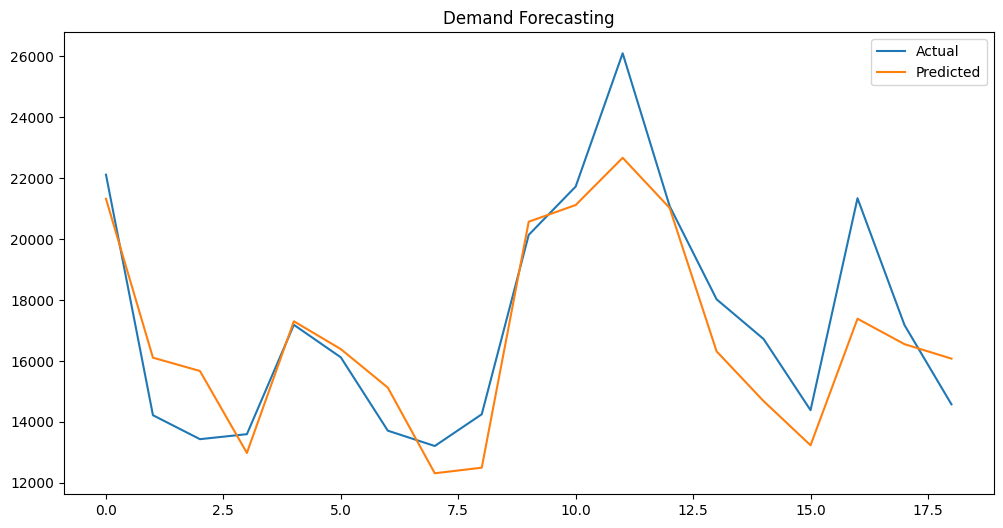

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    predictions,
    label='Predicted'
)

plt.legend()

plt.title("Demand Forecasting")

plt.show()

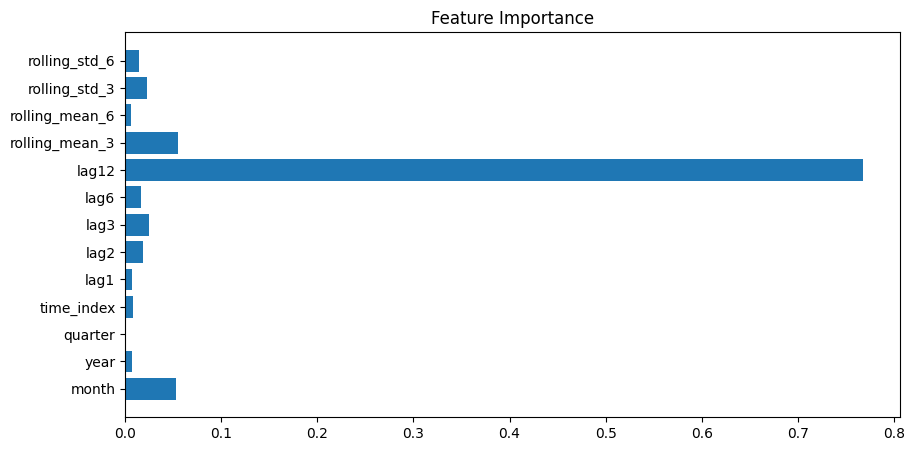

In [ ]:
importance = model.feature_importances_

features = X.columns

plt.figure(figsize=(10,5))

plt.barh(features,importance)

plt.title("Feature Importance")

plt.show()